<a href="https://colab.research.google.com/github/Shaikh-Uzair-Ahmed/1BM23CS307/blob/ML/1BM23CS307_LAB3_Logistic_Regression/LogisticRegression_Binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('/content/HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [2]:
print("DataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDistribution of 'left' column:")
print(df['left'].value_counts())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB

Descriptive Statistics:
       satisfaction_level  last_evaluation  number_project  \
count        14999.000000     14999.000000    14999.000000   
mean             0.612834         0.7161

In [3]:
print("Correlation Matrix:")
print(df.corr(numeric_only=True)['left'].sort_values(ascending=False))

Correlation Matrix:
left                     1.000000
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
Work_accident           -0.154622
satisfaction_level      -0.388375
Name: left, dtype: float64


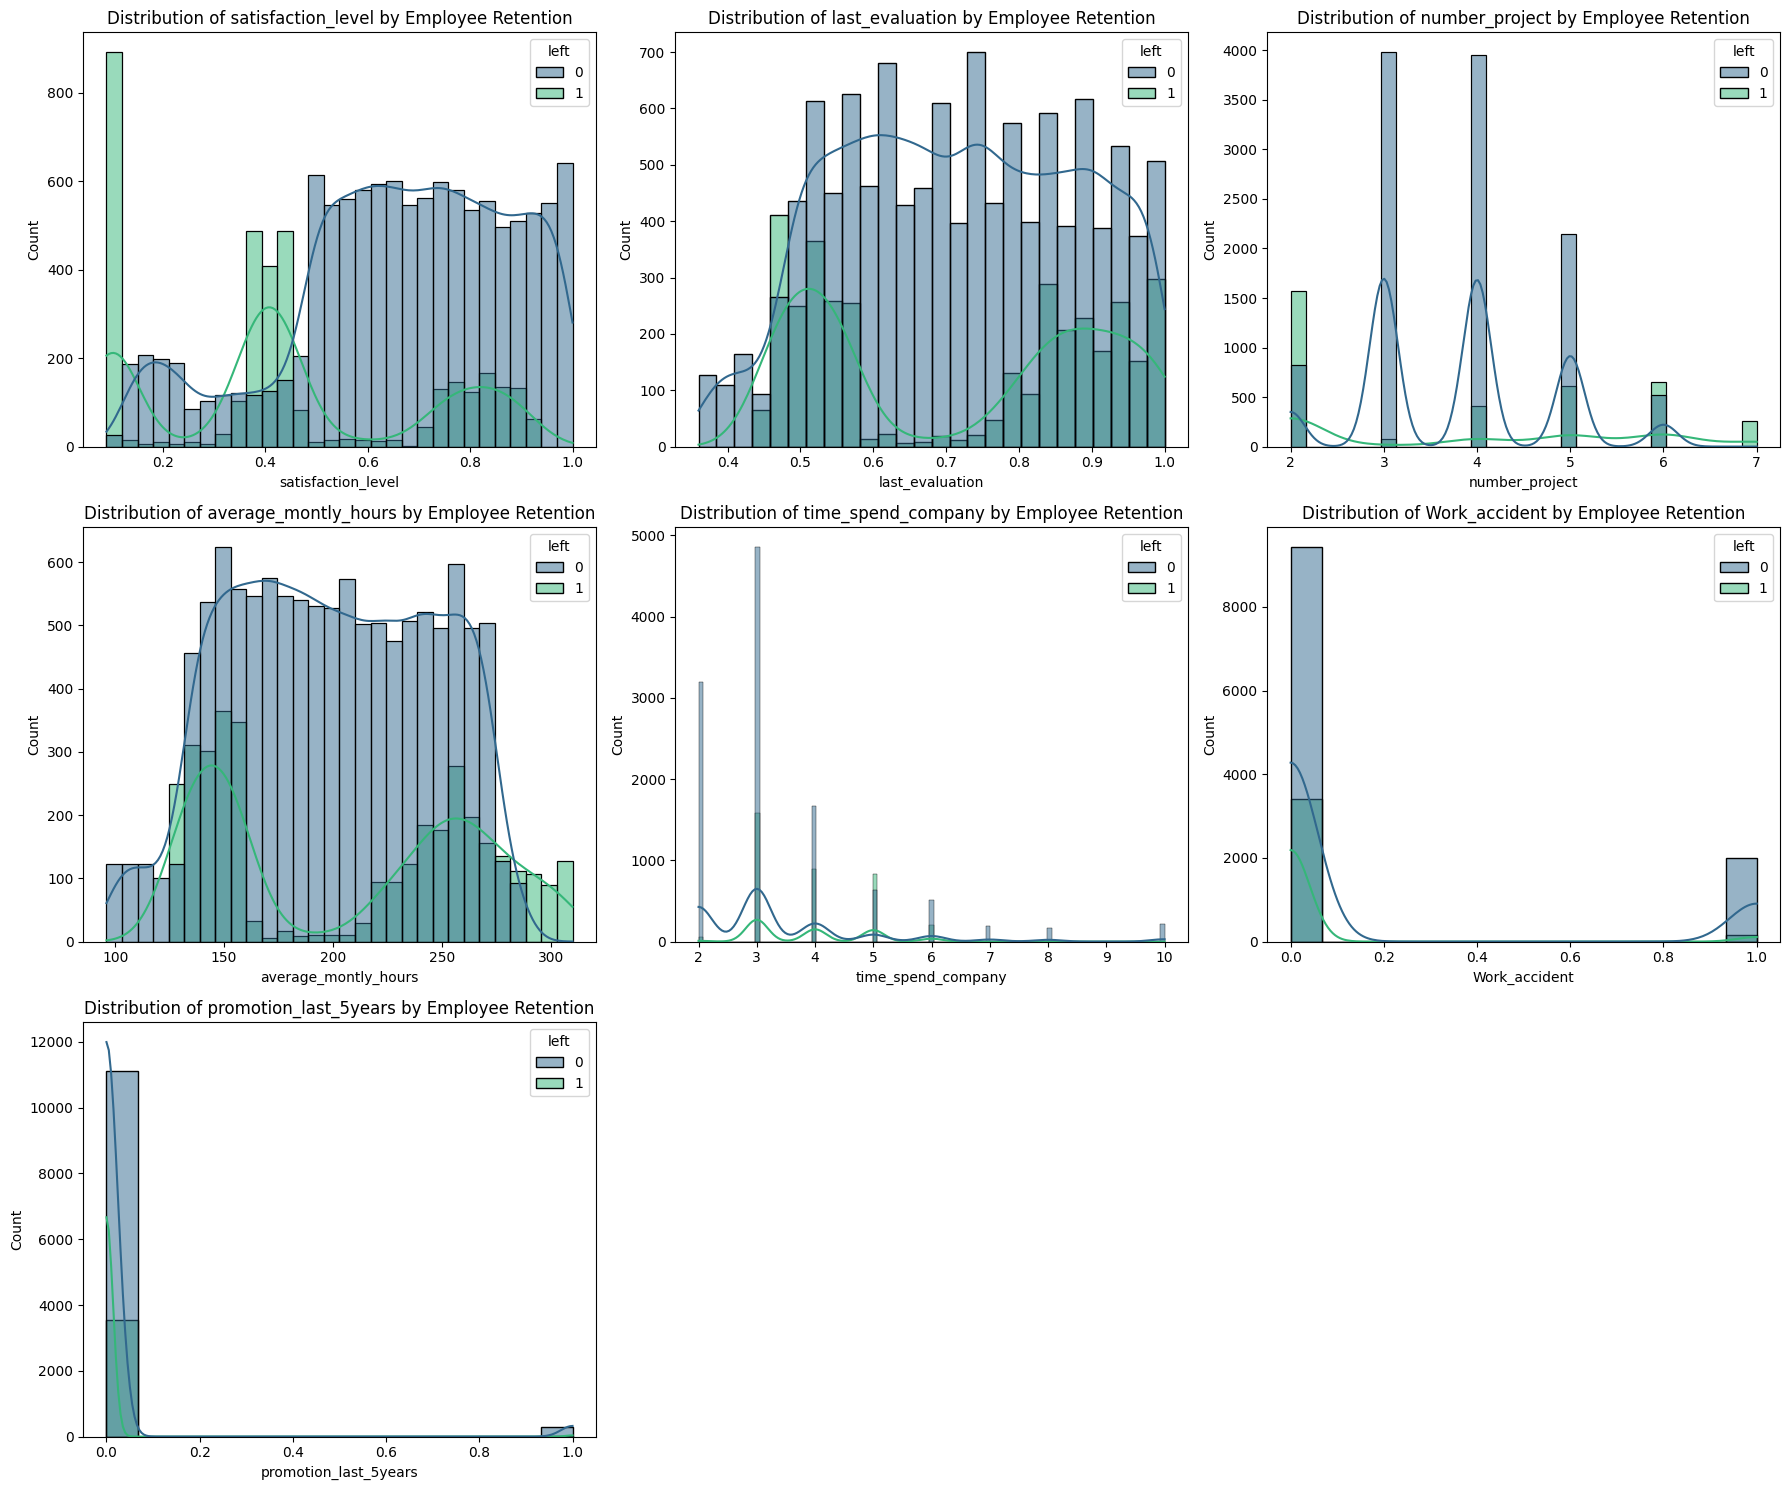

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('left')

plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(data=df, x=col, hue='left', kde=True, palette='viridis')
    plt.title(f'Distribution of {col} by Employee Retention')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()


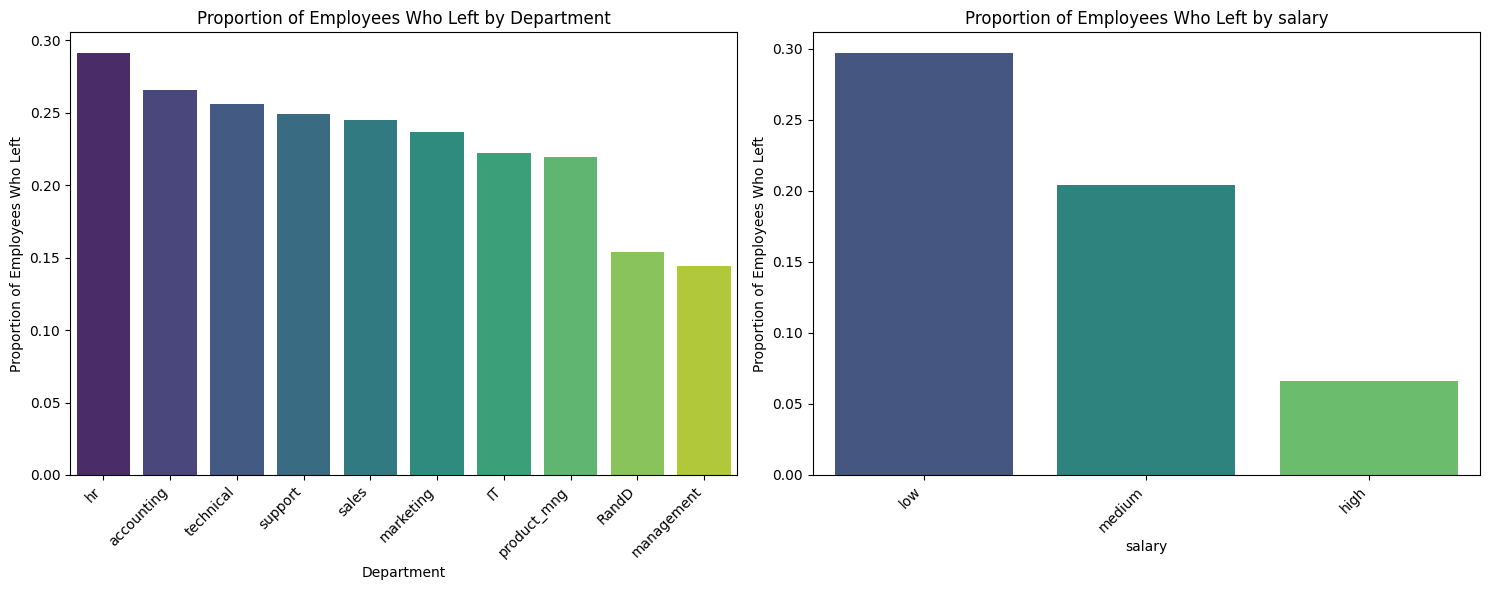

In [6]:
categorical_cols = ['Department', 'salary']

plt.figure(figsize=(15, 6))

for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i + 1)
    # Calculate the proportion of employees who left for each category
    left_proportions = df.groupby(col)['left'].value_counts(normalize=True).unstack().get(1, pd.Series(0, index=df[col].unique()))
    left_proportions = left_proportions.sort_values(ascending=False)

    sns.barplot(x=left_proportions.index, y=left_proportions.values, hue=left_proportions.index, palette='viridis', legend=False)
    plt.title(f'Proportion of Employees Who Left by {col}')
    plt.xlabel(col)
    plt.ylabel('Proportion of Employees Who Left')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [7]:
df_encoded = pd.get_dummies(df, columns=['Department', 'salary'], drop_first=True)
df_encoded.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Define feature matrix X and target vector y
X = df_encoded.drop('left', axis=1)
y = df_encoded['left']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42)

print("Data split into training and testing sets. Logistic Regression model initialized.")

Data split into training and testing sets. Logistic Regression model initialized.


In [9]:
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [10]:
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy on the Test Set: {accuracy:.4f}")

Model Accuracy on the Test Set: 0.7831
